## Thăm dò dữ liệu

In [31]:
# Đọc file dữ liệu đã được làm sạch
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/gold_cleaned.csv")
df["date"] = pd.to_datetime(df["date"])
df.head()

,date,open,high,low,close
0,2023-04-03,1970.84,1990.64,1949.82,1984.11
1,2023-04-04,1984.59,2025.19,1977.01,2019.97
2,2023-04-05,2020.44,2032.20,2009.99,2020.35
3,2023-04-06,2020.13,2021.63,2000.88,2008.02
4,2023-04-10,2008.30,2011.17,1981.59,1989.95


In [32]:
# Xem shape và khoảng thời gian của dữ liệu
print("Shape:", df.shape)
print("Từ ngày:", df["date"].min())
print("Đến ngày:", df["date"].max())

Shape: (775, 5)
Từ ngày: 2023-04-03 00:00:00
Đến ngày: 2026-04-08 00:00:00


In [33]:
# Thống kê mô tả cho các cột số liệu
print("\nThống kê mô tả:")
df[["open", "high", "low", "close"]].describe()

# count: giá trị không null
# mean: giá trị trung bình
# std: độ lệch chuẩn
# min: giá trị nhỏ nhất
# 25%: giá trị ở vị trí 25% (Q1)
# 50%: giá trị ở vị trí 50% (Q2, median)
# 75%: giá trị ở vị trí 75% (Q3)
# max: giá trị lớn nhất


Thống kê mô tả:


,open,high,low,close
count,775.000000,775.000000,775.000000,775.000000
mean,2851.324439,2877.884916,2826.861006,2854.293535
std,915.637386,932.953739,896.696282,916.803096
min,1820.400000,1829.300000,1810.100000,1820.010000
25%,2028.815000,2040.565000,2019.645000,2028.890000
50%,2613.070000,2628.610000,2602.500000,2613.200000
75%,3348.000000,3374.785000,3325.160000,3351.325000
max,5395.580000,5451.200000,5261.370000,5327.420000


In [34]:
# Kiểm tra missing values lần cuối
print("\nMissing values:")
df.isnull().sum()


Missing values:


date     0
open     0
high     0
low      0
close    0
dtype: int64

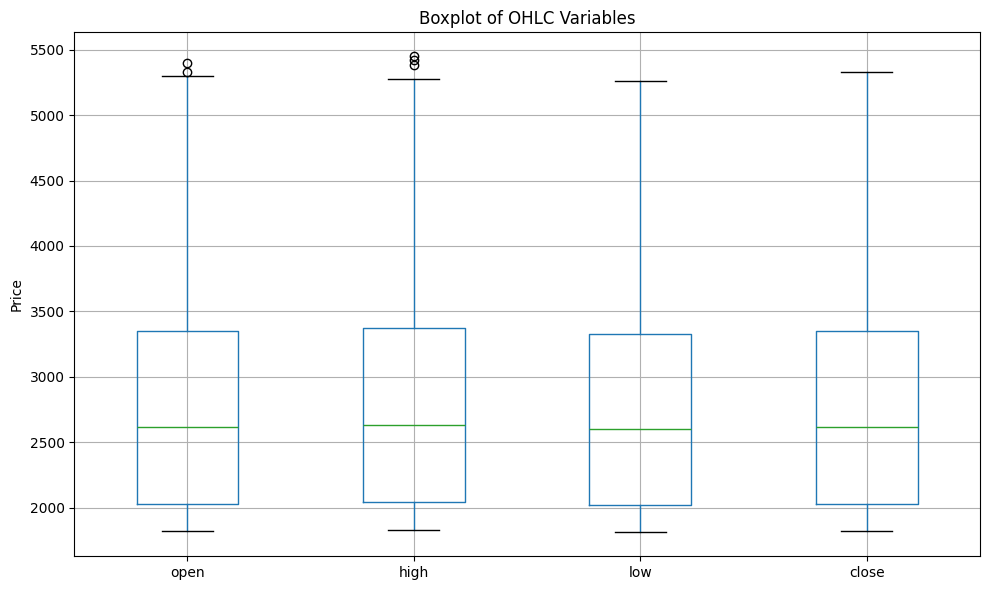

In [35]:
# Boxplot của tất cả các cột giá
import matplotlib.pyplot as plt

price_cols = ["open", "high", "low", "close"]

plt.figure(figsize=(10, 6))
df[price_cols].boxplot()
plt.title("Boxplot of OHLC Variables")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

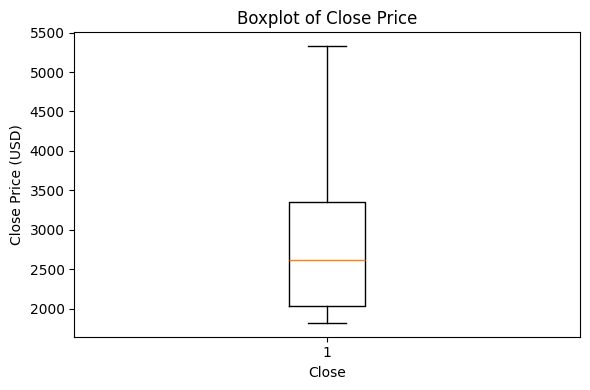

In [36]:
# Boxplot của giá đóng cửa
plt.figure(figsize=(6, 4))
plt.boxplot(df["close"])
plt.title("Boxplot of Close Price")
plt.ylabel("Close Price (USD)")
plt.xlabel("Close")
plt.tight_layout()
plt.show()

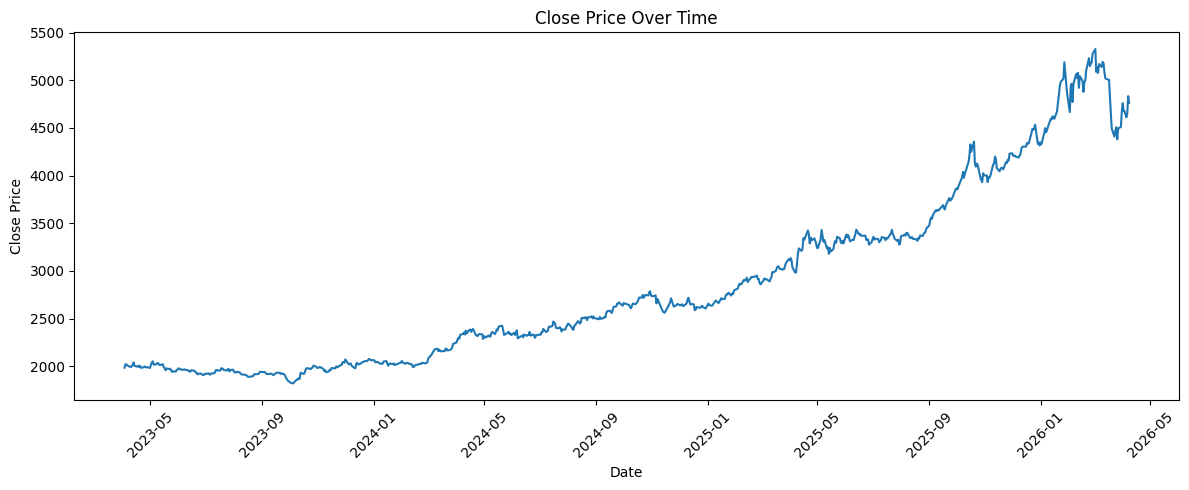

In [37]:
# Vẽ biểu đồ giá đóng cửa (close) theo thời gian
plt.figure(figsize=(12,5))
plt.plot(df["date"], df["close"])
plt.title("Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

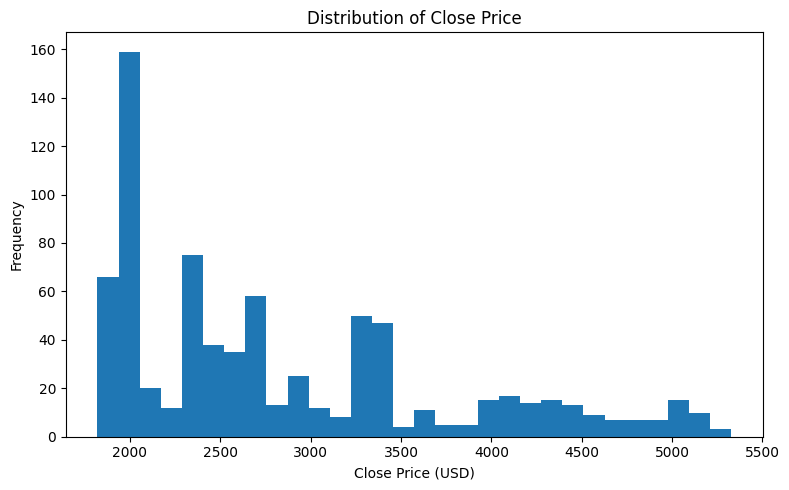

In [38]:
# Histogram của giá đóng cửa
plt.figure(figsize=(8,5))
plt.hist(df["close"], bins=30)
plt.title("Distribution of Close Price")
plt.xlabel("Close Price (USD)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
# Summary outlier bằng IQR sau khi đã xử lý dữ liệu

price_cols = ["open", "high", "low", "close"]

outlier_summary = {}

for col in price_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary[col] = {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    }

outlier_df = pd.DataFrame(outlier_summary).T.reset_index()
outlier_df = outlier_df.rename(columns={"index": "feature"})
outlier_df = outlier_df.round(4)

outlier_count_df = outlier_df[["feature", "Outlier Count"]].copy()
outlier_count_df = outlier_count_df.sort_values("Outlier Count", ascending=False)

outlier_count_df

,feature,Outlier Count
1,high,3.0
0,open,2.0
2,low,0.0
3,close,0.0


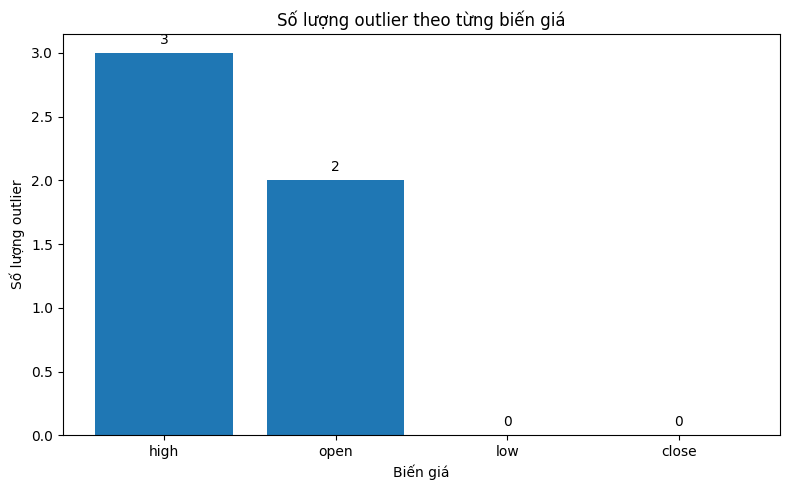

In [40]:
plt.figure(figsize=(8, 5))
bars = plt.bar(outlier_count_df["feature"], outlier_count_df["Outlier Count"])

plt.title("Số lượng outlier theo từng biến giá")
plt.xlabel("Biến giá")
plt.ylabel("Số lượng outlier")

# Hiển thị số trên đầu cột
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()